Successfully loaded Iris dataset.
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']

Data split: 120 training samples, 30 testing samples.
Features have been scaled.

Starting model training and evaluation...
--- Training: Solver: sgd, Activation: logistic ---


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


--- Training: Solver: sgd, Activation: tanh ---


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


--- Training: Solver: sgd, Activation: relu ---


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


--- Training: Solver: adam, Activation: logistic ---


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


--- Training: Solver: adam, Activation: tanh ---
--- Training: Solver: adam, Activation: relu ---
...Training complete.

--- Performance Metrics Comparison ---
| Model                              | Accuracy   | Precision (macro)   | Recall (macro)   | F1-Score (macro)   |
|:-----------------------------------|:-----------|:--------------------|:-----------------|:-------------------|
| Solver: sgd, Activation: logistic  | 0.933333   | 0.944444            | 0.933333         | 0.93266            |
| Solver: sgd, Activation: tanh      | 0.966667   | 0.969697            | 0.966667         | 0.966583           |
| Solver: sgd, Activation: relu      | 0.966667   | 0.969697            | 0.966667         | 0.966583           |
| Solver: adam, Activation: logistic | 1          | 1                   | 1                | 1                  |
| Solver: adam, Activation: tanh     | 1          | 1                   | 1                | 1                  |
| Solver: adam, Activation: relu     | 1  

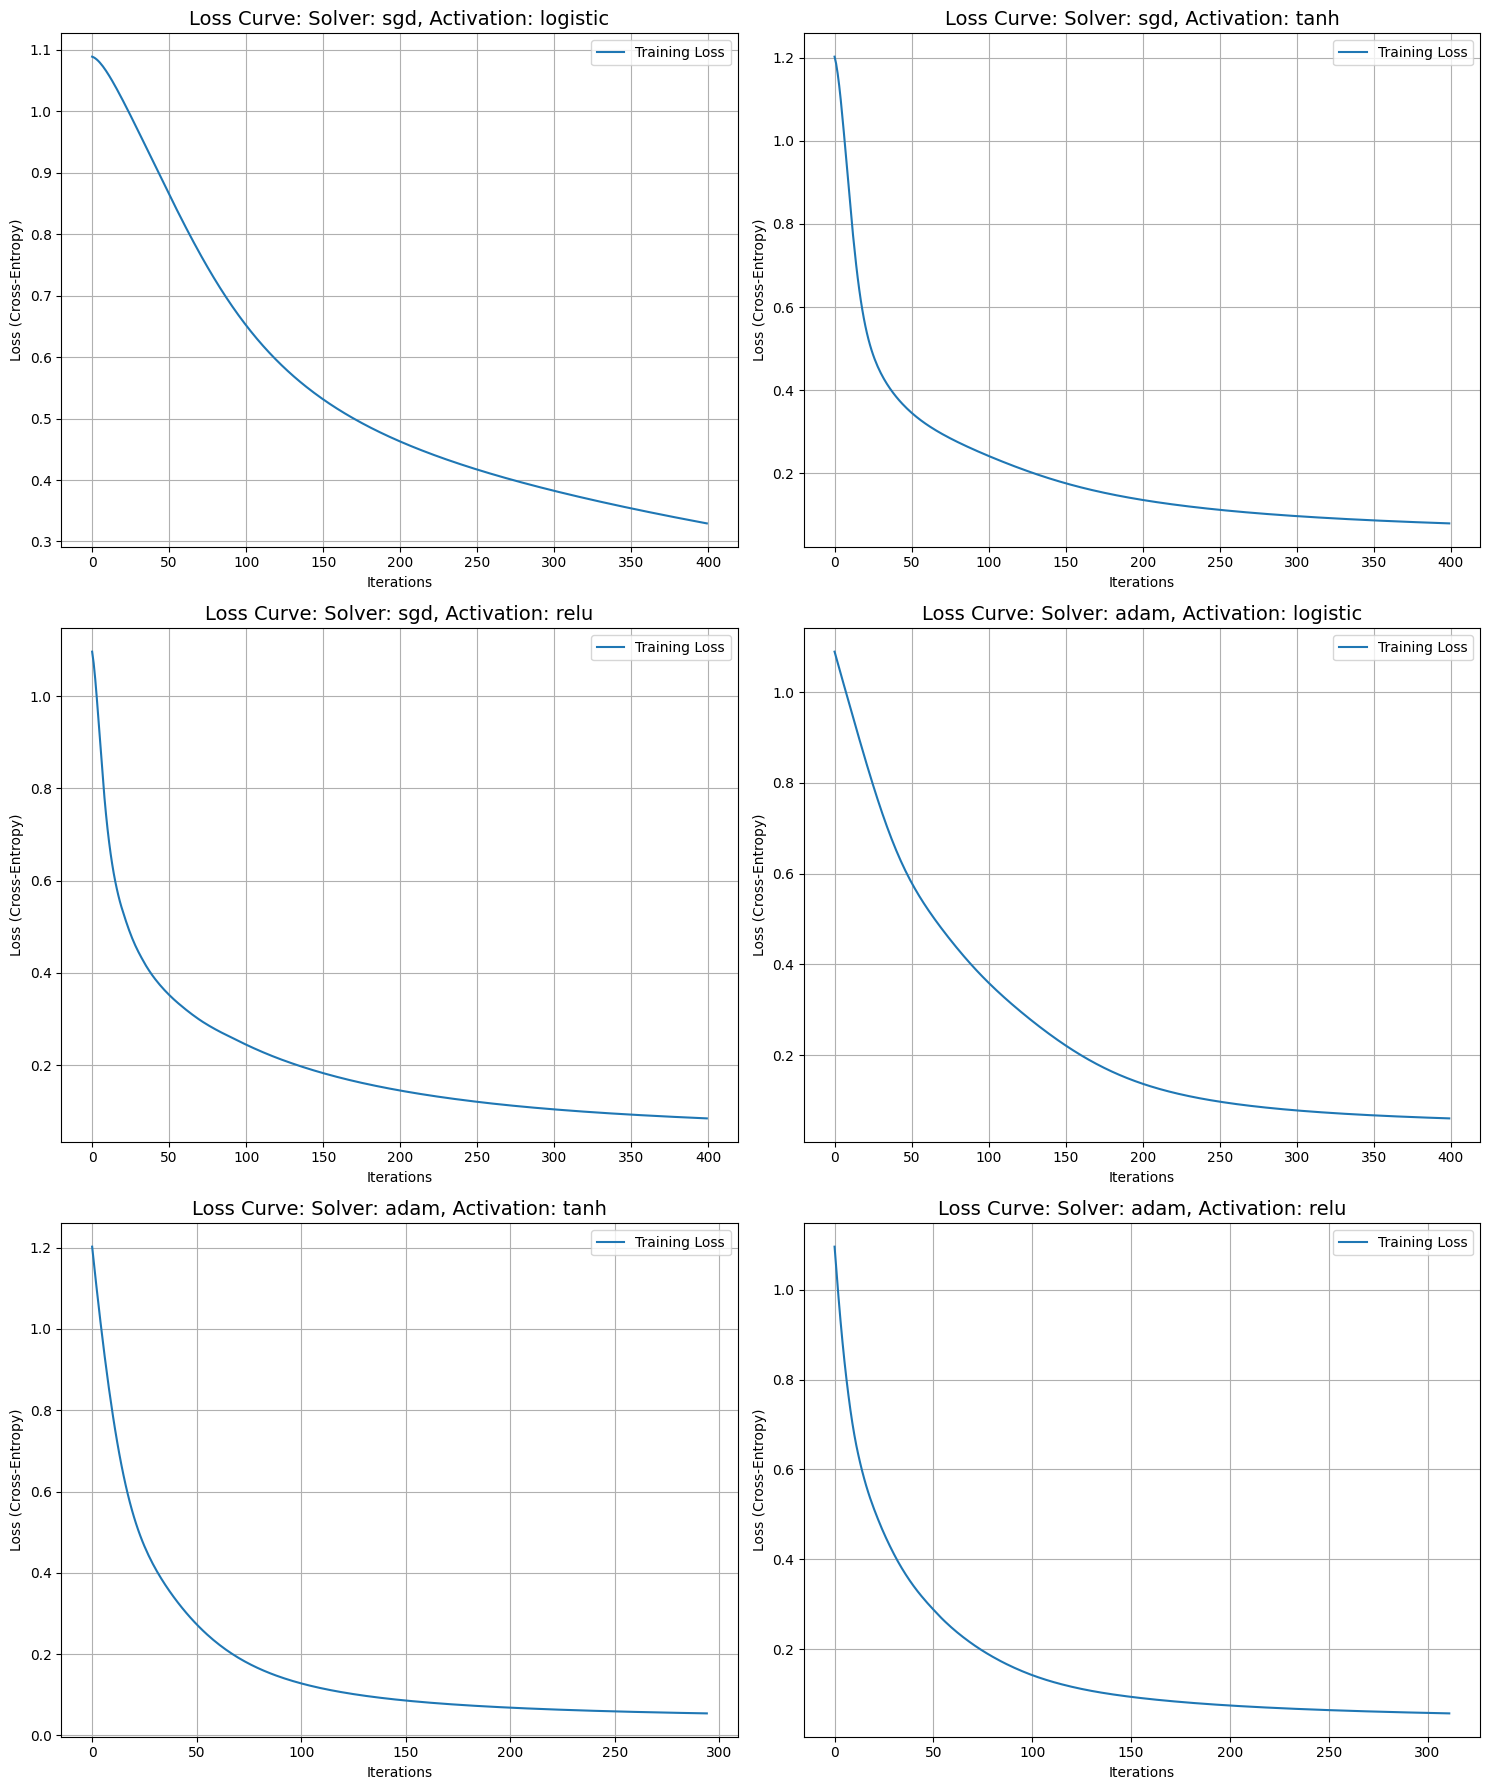

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

print("Successfully loaded Iris dataset.")
print(f"Features: {iris.feature_names}")
print(f"Classes: {target_names}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nData split: {len(X_train)} training samples, {len(X_test)} testing samples.")
print("Features have been scaled.")

activations_to_test = ['logistic', 'tanh', 'relu']
solvers_to_test = ['sgd', 'adam']

results_list = []
models_data = {}

print("\nStarting model training and evaluation...")

for solver in solvers_to_test:
    for activation in activations_to_test:

        model_name = f"Solver: {solver}, Activation: {activation}"
        print(f"--- Training: {model_name} ---")

        model = MLPClassifier(
            hidden_layer_sizes=(5,),
            activation=activation,
            solver=solver,
            max_iter=400,
            learning_rate_init=0.01,
            random_state=42
        )

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

        accuracy = accuracy_score(y_test, y_pred)
        report_dict = classification_report(
            y_test, y_pred, target_names=target_names,
            output_dict=True, zero_division=0
        )

        results_list.append({
            'Model': model_name,
            'Accuracy': accuracy,
            'Precision (macro)': report_dict['macro avg']['precision'],
            'Recall (macro)': report_dict['macro avg']['recall'],
            'F1-Score (macro)': report_dict['macro avg']['f1-score']
        })

        models_data[model_name] = model.loss_curve_

print("...Training complete.")

print("\n--- Performance Metrics Comparison ---")
results_df = pd.DataFrame(results_list)
print(results_df.to_markdown(index=False, numalign="left", stralign="left"))

print("\nGenerating Loss Curve plots...")

fig, axes = plt.subplots(3, 2, figsize=(15, 18), sharey=False)
axes = axes.flatten()

for i, (model_name, loss_curve) in enumerate(models_data.items()):
    ax = axes[i]
    ax.plot(loss_curve, label='Training Loss')
    ax.set_title(f"Loss Curve: {model_name}", fontsize=14)
    ax.set_xlabel('Iterations')
    ax.set_ylabel('Loss (Cross-Entropy)')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.savefig('mlp_loss_curves.png')
print("Saved plot: 'mlp_loss_curves.png'")